## Project #4 - Lab 2: Handling Missing Values
In this lab we will focus on how to deal with missing values, NA values and how to make decisions about the best methods for handling the values

In [2]:
## load in necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#import sys
#!{sys.executable} -m pip install scikit-learn


### **Handling missing values**

Missing values are often represented as *NA (Not Available)* or *NaN (Not a Number)*, is a crucial step in data preprocessing. 


Identifying NAs:
Use pandas.isna() or numpy.isnan() to detect missing values. These functions return a boolean mask indicating the location of NAs.

In [2]:
## Create a data set, and turn it into a pandas dataframe
data = {'col1': [1, 2, np.nan, 4], 'col2': [5, np.nan, 7, 8]}
df = pd.DataFrame(data)

## Use .isna() to check if values are NA
print(df.isna())

    col1   col2
0  False  False
1  False   True
2   True  False
3  False  False


Now what about in a dataframe?  If we import our NRI data, can we test out .isna() to see if we can find NAs in the data?

In [3]:
## Import the NRI dataset to check
ne_nri = pd.read_csv("NRI_Table_CensusTracts_Nebraska.csv", low_memory = True)
ne_nri = pd.DataFrame(ne_nri)

print(ne_nri.isna())

      OID_  NRI_ID  STATE  STATEABBRV  STATEFIPS  COUNTY  COUNTYTYPE  \
0    False   False  False       False      False   False       False   
1    False   False  False       False      False   False       False   
2    False   False  False       False      False   False       False   
3    False   False  False       False      False   False       False   
4    False   False  False       False      False   False       False   
..     ...     ...    ...         ...        ...     ...         ...   
548  False   False  False       False      False   False       False   
549  False   False  False       False      False   False       False   
550  False   False  False       False      False   False       False   
551  False   False  False       False      False   False       False   
552  False   False  False       False      False   False       False   

     COUNTYFIPS  STCOFIPS  TRACT  ...  WNTW_EALS  WNTW_EALR  WNTW_ALRB  \
0         False     False  False  ...      False      False  

Wow, that's pretty complete data!  This data set is very large so its going to be hard to see the NAs in the data.  What if we look at NAs in a different dataset for Water Quality violations in Kansas??  What happens then?

In [4]:
kansas_data = pd.read_csv("ViolationReport_Kansas_2024_Formatted.csv")
kansas_data.isna()

,state,pws_type,submission_year,epa_region_code,submission_quarter,primacy_agency,primary_source,pws_id,pws_name,season_start_date,...,owner_type,violation_code,violation_category,health_based,contaminant_code,major_violation,return_to_compliance_date,rule_name,violation_type,contaminant
0,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,True,True,False,False,False
2,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,True,True,False,False,False
3,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,True,True,False,False,False
4,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26115,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,True,True,False,False,False,True
26116,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,True,True,False,False,True
26117,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,True,True,True,False,False,True
26118,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,True,True,True,False,False,True


Aha!  So what we learn here is that Python sees empty spaces as NAs as well.  That's important to know because if you try to multiply a number by a row or column with an "NA" value, you will get an error in Python.  So therefore `isna()` is a good function to use to double check when you get error messages!

#### Lab Activity 1 - Locate NAs

In the cell below, show that you can use the `.isna()` function on one of your states from the NRI data set (not Nebraska).

In [6]:
## Student Activity:

nri_data = pd.read_csv("NRI_Table_CensusTracts.csv")
co_nri = nri_data[nri_data["STATE"] == "Colorado"]
co_nri.isna()

,OID_,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,...,WNTW_EALS,WNTW_EALR,WNTW_ALRB,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_NPCTL,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER
13306,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
13307,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
13308,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
13309,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
13310,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14748,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
14749,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
14750,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
14751,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### **Removing NAs**
Use pandas.DataFrame.dropna() to remove rows or columns containing NAs. Here's an example using randomly generated data to demonstrate.

In [5]:
df_dropped = df.dropna() #removes all rows with NA
df_dropped_cols = df.dropna(axis=1) #removes all cols with NA

Now let's try it with both the NRI dataset and the Project #1 Violation dataset to see what happens to the dataframe.

In [10]:
ne_nri_dropped = ne_nri.dropna() # remove all rows with NA

#print(ne_nri_dropped)

ne_nri_dropped_columns = ne_nri.dropna(axis = 1)

print(ne_nri_dropped_columns)

      OID_        NRI_ID     STATE STATEABBRV  STATEFIPS   COUNTY COUNTYTYPE  \
0    45054  T31001965400  Nebraska         NE         31    Adams     County   
1    45055  T31001965500  Nebraska         NE         31    Adams     County   
2    45056  T31001965600  Nebraska         NE         31    Adams     County   
3    45057  T31001965700  Nebraska         NE         31    Adams     County   
4    45058  T31001965800  Nebraska         NE         31    Adams     County   
..     ...           ...       ...        ...        ...      ...        ...   
548  45602  T31183973600  Nebraska         NE         31  Wheeler     County   
549  45603  T31185969600  Nebraska         NE         31     York     County   
550  45604  T31185969700  Nebraska         NE         31     York     County   
551  45605  T31185969800  Nebraska         NE         31     York     County   
552  45606  T31185969900  Nebraska         NE         31     York     County   

     COUNTYFIPS  STCOFIPS   TRACT  ... 

Wait a minute, what happened???  Because there is an NA at least somewhere in each column or row in the NRI dataset, when you run `ne_nri_dropped`, what happens is Python drops the **entire row** (yikes!), which is not what we meant to do.  But if we print `ne_nri_dropped_cols`, what we see is that instead of dropping rows, Python now drops columns where every value is an NA.  That's better data management, because we don't want to lose all of our data!  So be careful with dropping NAs.  In fact, its probably better to replace NAs, so that's what we're going to try next.

### Lab Activity 2 - Remove NAs

Using your own state data from the NRI, show that you have removed NAs in your state.

In [8]:
### Student Activity:
co_nri_dropped = co_nri.dropna()

co_nri_dropped_columns = co_nri.dropna(axis = 1)

print(co_nri_dropped_columns)



        OID_        NRI_ID     STATE STATEABBRV  STATEFIPS COUNTY COUNTYTYPE  \
13306  13307  T08001007801  Colorado         CO          8  Adams     County   
13307  13308  T08001007802  Colorado         CO          8  Adams     County   
13308  13309  T08001007900  Colorado         CO          8  Adams     County   
13309  13310  T08001008000  Colorado         CO          8  Adams     County   
13310  13311  T08001008100  Colorado         CO          8  Adams     County   
...      ...           ...       ...        ...        ...    ...        ...   
14748  14749  T08123002300  Colorado         CO          8   Weld     County   
14749  14750  T08123002501  Colorado         CO          8   Weld     County   
14750  14751  T08123002502  Colorado         CO          8   Weld     County   
14751  14752  T08125963100  Colorado         CO          8   Yuma     County   
14752  14753  T08125963200  Colorado         CO          8   Yuma     County   

       COUNTYFIPS  STCOFIPS   TRACT  ..

## **Replacing NAs - Imputation**

When we replace a NA value with a different value, we call this "imputation".  Imputation involves either replacing or calculating a replacement value for NA.  Use `pandas.DataFrame.fillna()` to replace NAs with a specific value, such as 0, the mean, median, or mode.  Let's try this with our test data set first.

In [12]:
## Fill the NA values with a zero
df_filled_0 = df.fillna(0)

## Fill the NA values with the mean of a dataframe
df_filled_mean = df.fillna(df.mean())

print(df_filled_mean)


       col1      col2
0  1.000000  5.000000
1  2.000000  6.666667
2  2.333333  7.000000
3  4.000000  8.000000


What we see here is that the NA values are replaced with either 0 in the first case, or the mean in the second case.  Choosing how you impute values does have an impact on the results of your analysis, so choosing your method (and defending your decision with sources) is important so that we communicate any potential bias to our clients when performing engineering analyses.

Let's try imputation with the `ne_nri` dataset.

In [16]:
## Imputate 0 for NAs
ne_nri_filled_0 = ne_nri.fillna(0)

## Imputate the mean for NAs
#ne_nri_filled_mean = ne_nri.fillna(ne_nri.mean())

print(ne_nri_filled_0)
#print(ne_nri_filled_mean)

      OID_        NRI_ID     STATE STATEABBRV  STATEFIPS   COUNTY COUNTYTYPE  \
0    45054  T31001965400  Nebraska         NE         31    Adams     County   
1    45055  T31001965500  Nebraska         NE         31    Adams     County   
2    45056  T31001965600  Nebraska         NE         31    Adams     County   
3    45057  T31001965700  Nebraska         NE         31    Adams     County   
4    45058  T31001965800  Nebraska         NE         31    Adams     County   
..     ...           ...       ...        ...        ...      ...        ...   
548  45602  T31183973600  Nebraska         NE         31  Wheeler     County   
549  45603  T31185969600  Nebraska         NE         31     York     County   
550  45604  T31185969700  Nebraska         NE         31     York     County   
551  45605  T31185969800  Nebraska         NE         31     York     County   
552  45606  T31185969900  Nebraska         NE         31     York     County   

     COUNTYFIPS  STCOFIPS   TRACT  ... 

#### Student Activity 3 - Imputation

In the cell below, using your state from the NRI dataset, complete the following:
1. Show the imputation method where you fill in the NA values with 0
2. Show another imputation method where you fill in the NA values with either the median, max or min.  You cannot use the mean!

In [10]:
## Student Activity:
co_nri_filled_0 = co_nri.fillna(0)
print(co_nri_filled_0)

        OID_        NRI_ID     STATE STATEABBRV  STATEFIPS COUNTY COUNTYTYPE  \
13306  13307  T08001007801  Colorado         CO          8  Adams     County   
13307  13308  T08001007802  Colorado         CO          8  Adams     County   
13308  13309  T08001007900  Colorado         CO          8  Adams     County   
13309  13310  T08001008000  Colorado         CO          8  Adams     County   
13310  13311  T08001008100  Colorado         CO          8  Adams     County   
...      ...           ...       ...        ...        ...    ...        ...   
14748  14749  T08123002300  Colorado         CO          8   Weld     County   
14749  14750  T08123002501  Colorado         CO          8   Weld     County   
14750  14751  T08123002502  Colorado         CO          8   Weld     County   
14751  14752  T08125963100  Colorado         CO          8   Yuma     County   
14752  14753  T08125963200  Colorado         CO          8   Yuma     County   

       COUNTYFIPS  STCOFIPS   TRACT  ..

### Replacing NAs - Interpolation

Another method when data is time series or has relationships between rows is to use interpolation. We use interpolation when data is sequential - that is, the data points appear in a specific sequence like time series data appears in order of date. Not all data is sequential so be very careful interpolating in a large dataset!  Sometimes imputation is better than interpolation and sometimes interpolation is better than imputation.  Removing NAs can lead to data loss, while imputation can introduce bias if not done carefully.  Let's try interpolation on the practice dataset and see how it differs from imputation.

In [17]:
## Try appending .interpolate() to our fake dataframe
df_interpolated = df.interpolate()
print(df_interpolated)



   col1  col2
0   1.0   5.0
1   2.0   6.0
2   3.0   7.0
3   4.0   8.0


So what we see here is that Python is using the values from the neighboring rows to calculate values to replace the NAs.  This is okay in sequential data, but might not be in the NRI dataset.  Let's look at the NRI dataset to see what will happen with interpolation and compare it to the imputation results.

In [21]:
##Try out interpolate with the NRI dataset
co_nri_interpolated = co_nri.interpolate()
print(co_nri_interpolated)


        OID_        NRI_ID     STATE STATEABBRV  STATEFIPS COUNTY COUNTYTYPE  \
13306  13307  T08001007801  Colorado         CO          8  Adams     County   
13307  13308  T08001007802  Colorado         CO          8  Adams     County   
13308  13309  T08001007900  Colorado         CO          8  Adams     County   
13309  13310  T08001008000  Colorado         CO          8  Adams     County   
13310  13311  T08001008100  Colorado         CO          8  Adams     County   
...      ...           ...       ...        ...        ...    ...        ...   
14748  14749  T08123002300  Colorado         CO          8   Weld     County   
14749  14750  T08123002501  Colorado         CO          8   Weld     County   
14750  14751  T08123002502  Colorado         CO          8   Weld     County   
14751  14752  T08125963100  Colorado         CO          8   Yuma     County   
14752  14753  T08125963200  Colorado         CO          8   Yuma     County   

       COUNTYFIPS  STCOFIPS   TRACT  ..

C:\Users\willm\AppData\Local\Temp\ipykernel_20752\3914899134.py:2: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  co_nri_interpolated = co_nri.interpolate()


### Converting Between Data Types

Prior to Project #4, we've used Excel to change strings to numbers, to format dates and to clean our data.  However, while that is comfortable, its not considered good data management practice.  Good data management practices emphasize that any manipulation of the data should happen inside a coding language so that none of the raw data is lost.  When people change the raw data, they are introducing unintentional bias into the data set immediately.  In the world of research, this is especially concerning because we want our results to be reproducible and replicable.  We're going to learn how to change from one data type to another in an example data set and in the NRI dataset so you can begin to practice good data management.  

Python allows for converting variables from one data type to another. This can be done explicitly using built-in functions or implicitly in certain operations.


**Explicit Type Conversion (Type Casting)**
 Python provides several built-in functions to explicitly convert data types:

1. `int()`: Converts a value to an integer data type.
2. `float()`: Converts a value to a floating-point number data type.
3. `str()`: Converts a value to a string data type.
4. `bool()`: Converts a value to a boolean data type.
5. `list()`, `tuple()`, `set()`: Convert values to list, tuple and set data types respectively.
Let's try this with randomly generated data first.

In [22]:
x = 10
y = 3.14
z = "hello"

# Convert int to float
a = float(x)
print(a)  # Output: 10.0
print(type(a)) # Output: <class 'float'>

# Convert float to int
b = int(y)
print(b)  # Output: 3
print(type(b)) # Output: <class 'int'>

# Convert int to string
c = str(x)
print(c)  # Output: "10"
print(type(c)) # Output: <class 'str'>

# Convert string to int
d = int("123")
print(d) # Output: 123
print(type(d)) # Output: <class 'int'>

#Convert string to float
e = float("3.14")
print(e) #Output: 3.14
print(type(e)) # Output: <class 'float'>

#Convert int to boolean
f = bool(x)
print(f) # Output: True
print(type(f)) # Output: <class 'bool'>

#Convert list to tuple
g = tuple([1, 2, 3])
print(g) # Output: (1, 2, 3)
print(type(g)) # Output: <class 'tuple'>

10.0
<class 'float'>
3
<class 'int'>
10
<class 'str'>
123
<class 'int'>
3.14
<class 'float'>
True
<class 'bool'>
(1, 2, 3)
<class 'tuple'>


Alright, so now that we have some examples, let's try this with the Kansas Water Quality Violation data.  Remember how some columns were formatted as strings when they should have been formatted as integers??  Let's pull in the data and see if we can change one of the string columns into an integer.

In [19]:
## Let's first check the datatype of each column
print(kansas_data.dtypes)

## It looks like major_violation is an object.  We probably want that as a string.
kansas_data['major_violation'] = kansas_data['major_violation'].astype(str)

##Maybe instead of int64 for population we want float64.
kansas_data['population'] = kansas_data['population'].astype(float)



state                         object
pws_type                      object
submission_year                int64
epa_region_code                int64
submission_quarter             int64
primacy_agency                object
primary_source                object
pws_id                        object
pws_name                      object
season_start_date             object
season_end_date               object
activity_status               object
population                     int64
connections                    int64
first_reported                object
last_reported                 object
owner_type                    object
violation_code                object
violation_category            object
health_based                  object
contaminant_code             float64
major_violation               object
return_to_compliance_date     object
rule_name                     object
violation_type                object
contaminant                   object
dtype: object


**Implicit Type Conversion**

Python automatically performs implicit type conversion in certain situations, such as during arithmetic operations involving different numeric types. In such cases, Python converts the lower-order data type to the higher-order data type to avoid data loss. It's important to note that not all data types can be converted to each other. For example, attempting to convert a string that does not represent a number to an integer or float will raise a `ValueError`

In [20]:
x = 10
y = 3.14

# Implicit conversion of int to float
z = x + y
print(z)


13.14


#### Student Activity 4 - Convert Data Types

Using your NRI state data, show that you have changed the data type of at least 2 columns.  In order to receive full credit, you must show the data types both before and after the conversion.

In [22]:
### Student Activity

print(co_nri.dtypes)

OID_                int64
NRI_ID             object
STATE              object
STATEABBRV         object
STATEFIPS           int64
                   ...   
WNTW_ALR_NPCTL    float64
WNTW_RISKV        float64
WNTW_RISKS        float64
WNTW_RISKR         object
NRI_VER            object
Length: 467, dtype: object


In [26]:
co_nri['OID_'] = co_nri['OID_'].astype(str)
co_nri['STATEFIPS'] = co_nri['STATEFIPS'].astype(float)
print(co_nri.dtypes)

OID_               object
NRI_ID             object
STATE              object
STATEABBRV         object
STATEFIPS         float64
                   ...   
WNTW_ALR_NPCTL    float64
WNTW_RISKV        float64
WNTW_RISKS        float64
WNTW_RISKR         object
NRI_VER            object
Length: 467, dtype: object


### Advanced Imputation Methods

In this section we will dive more deeply into imputation techniques.  First let's set up a dataset to work with.

In [21]:
# Let us create a Toy dataset that has missing values
data = {
    "Soil_Moisture": [23.5, 45.1, np.nan, 37.8, 29.2, np.nan, 41.0],
    "Land_Use": pd.Series(["Urban", "Agriculture", "Urban", np.nan, "Forest", "Urban", np.nan], dtype="category"),
    "Slope": [5.1, 3.2, 4.7, 6.3, 2.9, 3.5, 4.1]
}
toy_df = pd.DataFrame(data)


# Note: I used the function pd.Series to tell python that the input for Land_use is of data type "category".
# It is perfectly fine if you do not do that. The default of string data in python is "object"

In [22]:
# Let us see what are data is missing in our toy dataframe
print("Original dataset:")
print(toy_df)
missing = toy_df.isnull().sum()
missing = missing[missing>0].sort_values(ascending = False)
print(missing)


Original dataset:
   Soil_Moisture     Land_Use  Slope
0           23.5        Urban    5.1
1           45.1  Agriculture    3.2
2            NaN        Urban    4.7
3           37.8          NaN    6.3
4           29.2       Forest    2.9
5            NaN        Urban    3.5
6           41.0          NaN    4.1
Soil_Moisture    2
Land_Use         2
dtype: int64


In [23]:
# Let us see what data types are missing in each columns

types_missing =toy_df[missing.index].dtypes
print(types_missing)


Soil_Moisture     float64
Land_Use         category
dtype: object


In [29]:
# We can export the missing summary to excel to see it better

missing.to_csv("Missing_Values_Summary.csv", header = ["Missing_Count"])


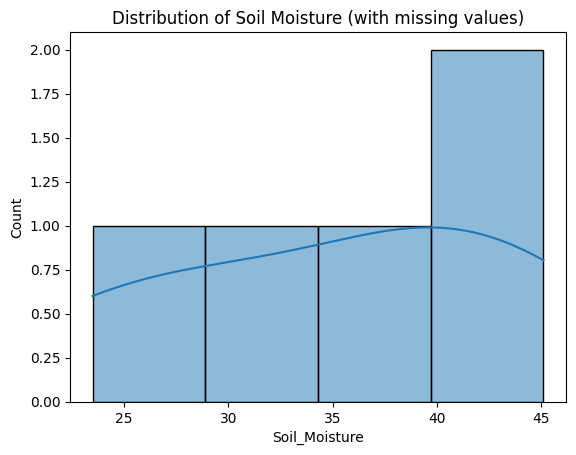

In [24]:
# We can also visualize the missing data by plots
sns.histplot(toy_df["Soil_Moisture"], kde = True)
plt.title("Distribution of Soil Moisture (with missing values)")
plt.show()




### Scientific Imputation Techniques
**Numeric Data Imputation**

In this section we're going to focus on a made up data set for soil moisture as a way to investigate how different methods of imputation can lead to unintential bias in our analyses.  Instead of having you try this with the NRI dataset, we have included a couple of places in the notebook for you to observe and reflect on coding.  Please make sure you complete these for full credit for today's Lab Activity.

In [26]:
# 1. Mean Imputation
mean_imputed = toy_df["Soil_Moisture"].fillna(toy_df["Soil_Moisture"].mean())
print(mean_imputed)

0    23.50
1    45.10
2    35.32
3    37.80
4    29.20
5    35.32
6    41.00
Name: Soil_Moisture, dtype: float64


In [27]:
# 2. Median Imputation
median_imputed = toy_df["Soil_Moisture"].fillna(toy_df["Soil_Moisture"].median())
print(median_imputed)

0    23.5
1    45.1
2    37.8
3    37.8
4    29.2
5    37.8
6    41.0
Name: Soil_Moisture, dtype: float64


#### Student Activity 5 - Mean vs. Median

Take a moment to reflect.  Does it make more sense to use the mean or the median in this example dataset?  What about in the real world?  What types of mistakes might you make if you used the mean instead of the median?

**Student Response:**

If you were to use the mean values, you run the risk of outliers influencing the extrapolated data. I think generally using the median would be a better option. With this dataset there doesn't seem to be any huge outliers, and looking at the results there isn't a huge difference between using the mean or the median. So for this case either could be used, but in a real world situation, median would be best.

In [28]:
# Predictive Imputation (using linear regression)
# This is an advanced way you can fill in numeric data by predictive analytics.

# For example, maybe `Soil_Moisture` is related to `Slope`.
# We will train a simple linear regression model that learns this relationship from the known (non-missing) values,
# and then uses that model to estimate what the missing values might be.
# This is often more accurate than just using the mean or median, especially if the predictor variable (e.g., slope)
# is strongly correlated with the variable that has missing data (e.g., soil moisture).

# This is mainly based on the sklearn package and is bit more advanced, but I would like you to see how it work
from sklearn.linear_model import LinearRegression


# Define features - This is the missing line that caused the error
features = pd.DataFrame(toy_df["Slope"]) # Slope is the predictor


# Create a new DataFrame with Soil_Moisture and its predictor(s)
predict_df = toy_df[["Soil_Moisture"]].join(features)
# Identify rows where Soil_Moisture is known (used for training)
train = predict_df[predict_df["Soil_Moisture"].notnull()]

# Create and train a linear regression model
lr = LinearRegression()
lr.fit(train[features.columns], train["Soil_Moisture"])  # Train model on known data

# Predict missing values directly from the full dataset
predicted_values = lr.predict(predict_df[features.columns][predict_df["Soil_Moisture"].isnull()])

# Fill in missing Soil_Moisture values with the model's predictions
predictive_imputed = toy_df["Soil_Moisture"].copy()
predictive_imputed.loc[predictive_imputed.isnull()] = predicted_values

# Print the predicted values
print(predictive_imputed)

0    23.500000
1    45.100000
2    34.941259
3    37.800000
4    29.200000
5    36.137283
6    41.000000
Name: Soil_Moisture, dtype: float64


**Categorical Data Imputation**

In [23]:
# 1. Mode Imputation

mode_imputed = toy_df["Land_Use"].fillna(toy_df["Land_Use"].mode()[0])

# toy_df["Land_Use"].mode() function finds the most frequent category (mode) in the column
# This returns a series e.g., ["Urban"], or possibly multiple values if there is a tie.
# the notation [0] selects the first mode in case there are multiple
# Then finally fillna(.) fills all the missing values in Lan_Use with that most frequent category

print(mode_imputed)

0          Urban
1    Agriculture
2          Urban
3          Urban
4         Forest
5          Urban
6          Urban
Name: Land_Use, dtype: category
Categories (3, object): ['Agriculture', 'Forest', 'Urban']


In [24]:
# 2. Predictive Imputation (Decision Tree Classifier)
# In this approach, we try to predict the missing category (Land_Use) using a machine learning model.
# A decision tree is a simple model that splits data into branches based on values in input variables like Slope.
# We train the tree on rows where Land_Use is not missing, and then use it to predict the missing values.
# Here we specifically use decision trees as it handles categorical type data well

from sklearn.tree import DecisionTreeClassifier

# Select Slope as the predictor variable for Land_Use
cat_features = toy_df[["Slope"]]
# Combine Land_Use with its predictor (Slope)
df_cat = toy_df[["Land_Use"]].join(cat_features)

# Keep only rows where Land_Use is known for training the model
train_cat = df_cat[df_cat["Land_Use"].notnull()]
# Keep only rows where Land_Use is missing (we want to predict these)
test_cat = df_cat[df_cat["Land_Use"].isnull()]

# Create the decision tree model
clf = DecisionTreeClassifier()
# Train the model using Slope to predict Land_Use
clf.fit(train_cat[["Slope"]], train_cat["Land_Use"])
# Predict missing Land_Use values
cat_predicted = clf.predict(test_cat[["Slope"]])

# Fill in missing values in Land_Use with predictions
predictive_cat_imputed = toy_df["Land_Use"].copy()
predictive_cat_imputed.loc[predictive_cat_imputed.isnull()] = cat_predicted

#Print the predicted values
print(predictive_cat_imputed)

0          Urban
1    Agriculture
2          Urban
3          Urban
4         Forest
5          Urban
6          Urban
Name: Land_Use, dtype: category
Categories (3, object): ['Agriculture', 'Forest', 'Urban']


### Bias Discussion

Each of the methods presented above will unintentionally introduce some kind of bias into our analysis.  Let's take a look at this in more detail below.

In [26]:
# Let's assume only Urban areas have missing data and we fill them using mean of the whole column
biased_df = toy_df.copy() # this creates a copy of the dataset and names it biased_df. I just do not want to rename the data or insert it again
biased_df.loc[(biased_df["Land_Use"] == "Urban") & (biased_df["Soil_Moisture"].isnull()), "Soil_Moisture"] = toy_df["Soil_Moisture"].mean()

In [27]:
# Let us check average soil moisture by land use before and after biased imputation
print("\nAverage Soil Moisture by Land Use (with original missing data):")
print(toy_df.groupby("Land_Use")["Soil_Moisture"].mean())

print("\nAverage Soil Moisture by Land Use (after biased imputation):")
print(biased_df.groupby("Land_Use")["Soil_Moisture"].mean())


Average Soil Moisture by Land Use (with original missing data):
Land_Use
Agriculture    45.1
Forest         29.2
Urban          23.5
Name: Soil_Moisture, dtype: float64

Average Soil Moisture by Land Use (after biased imputation):
Land_Use
Agriculture    45.10
Forest         29.20
Urban          31.38
Name: Soil_Moisture, dtype: float64


C:\Users\klane11\AppData\Local\Temp\ipykernel_29108\2728391326.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(toy_df.groupby("Land_Use")["Soil_Moisture"].mean())
C:\Users\klane11\AppData\Local\Temp\ipykernel_29108\2728391326.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(biased_df.groupby("Land_Use")["Soil_Moisture"].mean())


**Mean/Median Imputation** assumes data is missing completely at random (MCAR).
This can distort distributions and reduce variability.
 - **Predictive Imputation** assumes that the missingness can be explained by other variables,
   which introduces modeling bias if incorrect.
 - **Categorical Mode Imputation** may overrepresent the dominant class.
 - **Predictive Categorical Imputation** risks overfitting and depends on the quality of predictors.

 Best practices involve:
 - Understanding why data is missing (MCAR vs MAR vs MNAR)
 - Trying multiple imputation methods and comparing outcomes
 - Considering multiple imputation for uncertainty quantification





#### Student Activity 6 - 3 key learning about bias

We've learned a lot about bias in coding and data analysis today in both lecture and lab.  In the space below, type out three key things you learned about coding bias from lecture and lab today!

**Student Response:**

Fill in this cell!!!

1. It's important to understand why there is missing information. Knowing this can help you better chose a method for data imputation.
2. I think it's important to look at how using different imputation processes impacts the data. Do they give wildly different results, why is that? What can that tell you about the data?
3. I would assume thatpredicitive imputation would always be the best option. However, depending on the available data and the data that is missing, it could lead to unforseen bias.